# Weekly Training Summary

Loads the consolidated `coach_input_{monday}.json` and displays an interactive overview of the current training week.

Run `python scripts/prepare_week_for_coach.py` before opening this notebook so the latest `coach_input_{monday}.json` is available in `data/processed/`.

In [1]:
import json
from datetime import date, timedelta
from pathlib import Path

import pandas as pd

PROCESSED_DIR = Path("..") / "data" / "processed"

today = date.today()
monday = today - timedelta(days=today.weekday())
input_file = PROCESSED_DIR / f"coach_input_{monday.isoformat()}.json"

if not input_file.exists():
    files = sorted(PROCESSED_DIR.glob("coach_input_*.json"))
    input_file = files[-1]

data = json.loads(input_file.read_text())
print(f"Loaded: {input_file.name}")
print(f"Week starting: {data['week_starting']}")

Loaded: coach_input_2026-06-22.json
Week starting: 2026-06-22


## Athlete Metrics

This section combines current performance and wellness data, including FTP, power profile, CTL/ATL, HRV, sleep, body metrics, and simplified wellness trends (current, avg_7d, avg_prev_7d, trend_7d).

In [2]:
m = data.get("metrics", {})
pp = m.get("power_profile") or {}
weight = m.get("weight") or 0


def w_per_kg(watts):
    if watts and weight:
        return round(watts / weight, 2)
    return None


metrics_display = {
    "Age": m.get("age"),
    "Sex": m.get("sex"),
    "Weight (kg)": weight,
    "Sleep (h)": round((m.get("sleep_secs") or 0) / 3600, 2) if m.get("sleep_secs") is not None else None,
    "Sleep Quality (1=very good, 4=poor)": m.get("sleep_quality"),
    "FTP (W)": m.get("ftp"),
    "FTP (W/kg)": w_per_kg(m.get("ftp")),
    "Rolling FTP (W)": m.get("rolling_ftp"),
    "Rolling FTP (W/kg)": w_per_kg(m.get("rolling_ftp")),
    "eFTP (W)": round(m.get("eftp", 0), 1),
    "eFTP (W/kg)": w_per_kg(m.get("eftp")),
    "VO2Max (calc.)": m.get("vo2max"),
    "W’ (J)": m.get("w_prime"),
    "Rolling W’ (J)": round(m.get("rolling_w_prime", 0), 1) if m.get("rolling_w_prime") is not None else None,
    "Best 15s Power (W)": pp.get("p15s", {}).get("watts"),
    "Best 15s Power (W/kg)": pp.get("p15s", {}).get("w_per_kg"),
    "Best 30s Power (W)": pp.get("p30s", {}).get("watts"),
    "Best 30s Power (W/kg)": pp.get("p30s", {}).get("w_per_kg"),
    "Best 1-min Power (W)": pp.get("p1min", {}).get("watts"),
    "Best 1-min Power (W/kg)": pp.get("p1min", {}).get("w_per_kg"),
    "Best 3-min Power (W)": pp.get("p3min", {}).get("watts"),
    "Best 3-min Power (W/kg)": pp.get("p3min", {}).get("w_per_kg"),
    "Best 5-min Power (W)": pp.get("p5min", {}).get("watts"),
    "Best 5-min Power (W/kg)": pp.get("p5min", {}).get("w_per_kg"),
    "Best 20-min Power (W)": pp.get("p20min", {}).get("watts"),
    "Best 20-min Power (W/kg)": pp.get("p20min", {}).get("w_per_kg"),
    "Power Curve Slope": pp.get("curve_slope"),
    "Power Profile Period (days)": pp.get("period_days"),
    "CTL": round(m.get("ctl", 0), 1),
    "ATL": round(m.get("atl", 0), 1),
    "Resting HR (bpm)": m.get("resting_hr"),
    "Threshold HR / LTHR (bpm)": m.get("lthr"),
    "Max HR (bpm)": m.get("max_hr"),
    "HRV": m.get("hrv"),
}

display(pd.DataFrame(list(metrics_display.items()), columns=["Metric", "Value"]).set_index("Metric"))

wellness_trends = m.get("wellness_trends") or {}

trend_rows = []
trend_config = [
    ("weight", "Weight", "kg"),
    ("resting_hr", "Resting HR", "bpm"),
    ("hrv", "HRV", "ms"),
]

for key, label, unit in trend_config:
    t = wellness_trends.get(key) or {}
    trend_rows.append({
        "Metric": label,
        "Current": t.get("current"),
        "Avg 7d": t.get("avg_7d"),
        "Avg prev 7d": t.get("avg_prev_7d"),
        "Trend 7d": t.get("trend_7d"),
        "Unit": unit,
    })

print("\nWellness Trends (simplified):")
pd.DataFrame(trend_rows).set_index("Metric")

,Value
Metric,
Age,65
Sex,Male
Weight (kg),76.12
Sleep (h),6.3
"Sleep Quality (1=very good, 4=poor)",AVG
FTP (W),265
FTP (W/kg),3.48
Rolling FTP (W),248
Rolling FTP (W/kg),3.26



Wellness Trends (simplified):


,Current,Avg 7d,Avg prev 7d,Trend 7d,Unit
Metric,,,,,
Weight,76.12,76.84,NaN,NaN,kg
Resting HR,43.00,43.43,42.71,stable,bpm
HRV,57.00,51.00,51.29,stable,ms


## Power Profile (42-Day Best)

This section shows the athlete's best recent power values across key durations from 15 seconds to 20 minutes, both in absolute watts and relative watts per kilogram. It helps identify whether the rider profile is more anaerobic / punchy or more aerobic / climbing-oriented.

Matplotlib is building the font cache; this may take a moment.


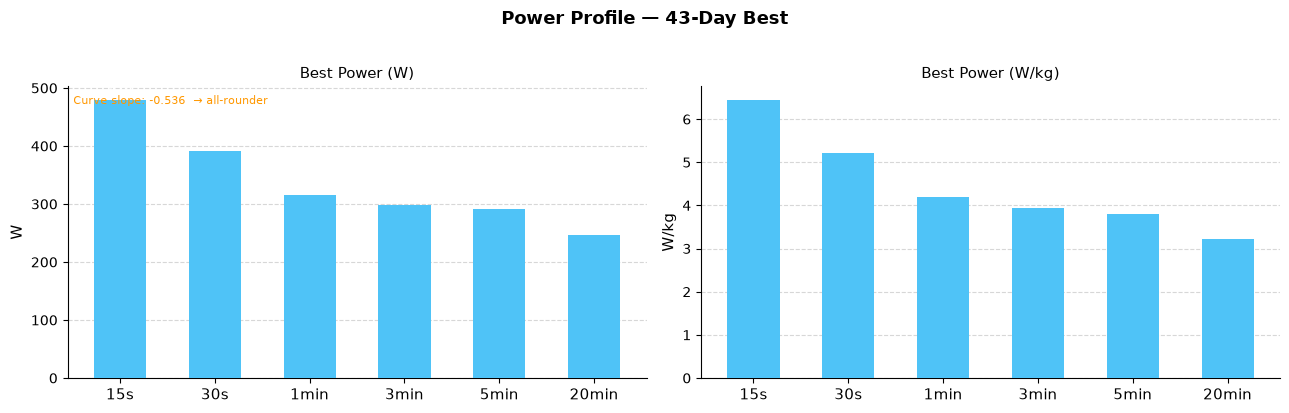

In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

pp = m.get("power_profile") or {}

# Key durations in seconds and their display labels
DURATIONS = [
    (15,   "15s"),
    (30,   "30s"),
    (60,   "1min"),
    (180,  "3min"),
    (300,  "5min"),
    (1200, "20min"),
]
KEYS      = ["p15s", "p30s", "p1min", "p3min", "p5min", "p20min"]
dur_secs  = [d[0]   for d in DURATIONS]
dur_label = [d[1]   for d in DURATIONS]
watts_vals = [pp.get(k, {}).get("watts")   for k in KEYS]
wkg_vals   = [pp.get(k, {}).get("w_per_kg") for k in KEYS]
slope      = pp.get("curve_slope")
period     = pp.get("period_days", 42)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f"Power Profile — {period}-Day Best", fontsize=13, fontweight="bold", y=1.02)

BAR_COLOR = "#4fc3f7"
ACCENT    = "#ff9800"

for ax, vals, unit in zip(axes, [watts_vals, wkg_vals], ["W", "W/kg"]):
    x = np.arange(len(dur_label))
    bars = ax.bar(x, [v if v else 0 for v in vals], color=BAR_COLOR, width=0.55, zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(dur_label, fontsize=11)
    ax.set_ylabel(unit, fontsize=11)
    ax.set_title(f"Best Power ({unit})", fontsize=11)
    ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    for bar, val in zip(bars, vals):
        if val:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(v for v in vals if v) * 0.01,
                f"{val}",
                ha="center", va="bottom", fontsize=9, color="white",
            )

# Annotate slope in the W chart
if slope is not None:
    slope_label = f"Curve slope: {slope:.3f}"
    if slope > -0.50:
        rider_hint = "→ anaerobic / puncheur"
    elif slope > -0.60:
        rider_hint = "→ all-rounder"
    else:
        rider_hint = "→ aerobic / climber"
    axes[0].annotate(
        f"{slope_label}  {rider_hint}",
        xy=(0.01, 0.97), xycoords="axes fraction",
        fontsize=8, color=ACCENT, va="top",
    )

plt.tight_layout()
plt.show()


## Weekly Training Plan Overview

This section shows plan context for the current and next week, including plan phase, weekly load target, optional week note, and day-level constraints (e.g. Sick/Travel/Unavailable).

Use it to compare intended training constraints with completed rides and weekly load shown in the sections below.

In [4]:
ws = data.get("week_summary", {})
tp = ws.get("training_plan")

if tp:
    # Support both old dict format and new list format
    if isinstance(tp, dict):
        tp = [tp]

    rows = []
    constraint_rows = []

    for entry in tp:
        week = entry.get("week", "")
        plan_name = entry.get("plan_name") or "Training Plan"
        phase = entry.get("phase")
        load = entry.get("weekly_load_target")
        week_note = entry.get("week_note") or ""
        day_constraints = entry.get("day_constraints") or []

        rows.append({
            "Week": week,
            "Plan": plan_name,
            "Phase": f"#{phase}" if phase else "(no phase)",
            "Phase Period": f"{entry.get('phase_start', '')} → {entry.get('phase_end', '')}",
            "Load Target": f"{load} TSS" if load is not None else "(none)",
            "Week Note": week_note,
            "Constraint Days": len(day_constraints),
        })

        for c in day_constraints:
            constraint_rows.append({
                "Week": week,
                "Date": c.get("date"),
                "Type": c.get("type"),
                "Training Allowed": c.get("training_allowed"),
                "Source": c.get("source_category"),
                "Label": c.get("source_name"),
            })

    display(pd.DataFrame(rows).set_index("Week"))

    if constraint_rows:
        print("\nDay Constraints (Sick/Travel/Unavailable):")
        display(pd.DataFrame(constraint_rows))
else:
    print("No training plan data available — run get_training_plan.py first.")

,Plan,Phase,Phase Period,Load Target,Week Note,Constraint Days
Week,,,,,,
2026-06-22,TdF Alpen,#Peak,2026-06-15 → 2026-07-20,349 TSS,,0
2026-06-29,TdF Alpen,#Peak,2026-06-15 → 2026-07-20,234 TSS,Recovery Week,0


This block summarizes the training units already completed this week, including ride count, total load, total duration, key session types, and overall endurance drift.

In [5]:
ws = data.get("week_summary", {})

week_display = {
    "Rides": ws.get("number_of_rides"),
    "Total Load": ws.get("total_training_load"),
    "Total Time (h)": round(ws.get("total_time_hours", 0), 1),
    "Longest Ride (h)": round(ws.get("longest_ride_hours", 0), 1),
    "VO2 Sessions": ws.get("vo2_sessions"),
    "Threshold Sessions": ws.get("threshold_sessions"),
    "Long Ride Sessions": ws.get("long_ride_sessions"),
    "Endurance Sessions": ws.get("endurance_sessions"),
    "Avg Decoupling (%)": round(ws.get("avg_decoupling", 0), 1),
    "Avg Decoupling Label": ws.get("avg_decoupling_label", ""),
    "Rides with high drift or worse (>=8%)": ws.get("high_decoupling_rides"),
}

pd.DataFrame(list(week_display.items()), columns=["Metric", "Value"]).set_index("Metric")

,Value
Metric,
Rides,4
Total Load,346
Total Time (h),9.7
Longest Ride (h),3.7
VO2 Sessions,1
Threshold Sessions,1
Long Ride Sessions,0
Endurance Sessions,2
Avg Decoupling (%),9.8


## Activities

This table shows the 10 most recent completed activities (newest first).

In [6]:
activities = data.get("activities", [])
df = pd.DataFrame(activities)

if "date" in df.columns:
    df = df.sort_values("date", ascending=False)

cols = [
    "date", "name", "duration_hours", "ride_type",
    "training_load", "avg_power", "norm_power",
    "polarization_index", "training_distribution",
    "z1_z2_pct", "z3_z4_pct", "z5_plus_pct",
    "decoupling", "rpe", "carbs_used_g", "carbs_ingested_g",
    "w_prime_j", "w_prime_bal_drop_j", "w_prime_bal_min_j", "w_prime_usage_pct",
]
cols = [c for c in cols if c in df.columns]
df[cols].head(10)


,date,name,duration_hours,training_load,avg_power,norm_power,polarization_index,training_distribution,z1_z2_pct,z3_z4_pct,z5_plus_pct,decoupling,rpe,carbs_used_g,carbs_ingested_g,w_prime_j,w_prime_bal_drop_j,w_prime_bal_min_j,w_prime_usage_pct
0,2026-06-27,WTT,3.68,124,123,154,0.67,Pyramidal,83.6,10.4,0.5,25.527287,5,413,360,20434,1515,18919,7.4
1,2026-06-25,Into the Nightride,2.46,71,122,142,1.02,Base,94.7,3.7,0.4,6.253812,4,255,160,20434,2024,18410,9.9
2,2026-06-24,5 x VO2Max Out of Berrenrath,1.54,88,144,200,2.11,Polarized,75.4,8.4,14.2,3.903757,8,270,75,20434,7914,12520,38.7
3,2026-06-22,Flughafen geht immer,1.98,63,130,149,0.63,Base,92.5,5.4,0.2,3.708465,3,248,80,20434,454,19980,2.2
4,2026-06-20,5 x 2m VO2Max am Hausberg,0.65,45,163,220,2.87,HIIT,72.6,2.4,24.5,8.541398,8,171,0,20434,9553,10881,46.8
5,2026-06-18,Stilfser Joch - Bergevent,5.61,205,130,160,-0.07,Pyramidal,82.8,13.9,0.1,29.503887,6,602,500,20434,349,20085,1.7
6,2026-06-15,Kleine Runde mit Höhenmetern,1.46,50,115,155,0.67,Pyramidal,83.4,11.4,0.6,13.207342,3,202,40,20434,746,19688,3.7


In [7]:
# Interval-level HR from intervals.icu segments (avg + max per segment)
segment_rows = []
for act in data.get("activities", []):
    segments = act.get("interval_segments") or []
    for i, seg in enumerate(segments, start=1):
        elapsed = seg.get("elapsed_time")
        segment_rows.append({
            "date": act.get("date"),
            "activity": act.get("name"),
            "segment_no": i,
            "type": seg.get("type"),
            "duration_min": round(elapsed / 60, 2) if elapsed is not None else None,
            "avg_power": seg.get("avg_power"),
            "avg_hr": seg.get("avg_hr"),
            "max_hr": seg.get("max_hr"),
            "intensity_pct": seg.get("intensity_pct"),
            "zone": seg.get("zone"),
        })

if segment_rows:
    seg_df = pd.DataFrame(segment_rows).sort_values(["date", "activity", "segment_no"], ascending=[False, True, True])
    display(seg_df)

    print("\nWORK segments only:")
    work_df = seg_df[seg_df["type"] == "WORK"].copy()
    if not work_df.empty:
        display(work_df)
    else:
        print("No WORK segments available.")
else:
    print("No interval_segments found in coach_input.")

,date,activity,segment_no,type,duration_min,avg_power,avg_hr,max_hr,intensity_pct,zone
0,2026-06-27,WTT,1,RECOVERY,53.90,126,128,150,47,1
1,2026-06-27,WTT,2,WORK,2.20,241,156,162,90,4
2,2026-06-27,WTT,3,RECOVERY,52.85,130,137,161,49,1
3,2026-06-27,WTT,4,WORK,11.20,251,169,179,94,4
4,2026-06-27,WTT,5,RECOVERY,130.57,104,133,173,39,1
5,2026-06-25,Into the Nightride,1,RECOVERY,161.20,123,113,147,46,1
6,2026-06-24,5 x VO2Max Out of Berrenrath,1,RECOVERY,39.17,140,121,142,52,1
7,2026-06-24,5 x VO2Max Out of Berrenrath,2,WORK,2.57,299,158,169,112,5
8,2026-06-24,5 x VO2Max Out of Berrenrath,3,RECOVERY,2.95,39,115,168,14,1
9,2026-06-24,5 x VO2Max Out of Berrenrath,4,WORK,2.58,305,151,170,115,5



WORK segments only:


,date,activity,segment_no,type,duration_min,avg_power,avg_hr,max_hr,intensity_pct,zone
1,2026-06-27,WTT,2,WORK,2.20,241,156,162,90,4
3,2026-06-27,WTT,4,WORK,11.20,251,169,179,94,4
7,2026-06-24,5 x VO2Max Out of Berrenrath,2,WORK,2.57,299,158,169,112,5
9,2026-06-24,5 x VO2Max Out of Berrenrath,4,WORK,2.58,305,151,170,115,5
11,2026-06-24,5 x VO2Max Out of Berrenrath,6,WORK,2.58,305,156,171,115,5
13,2026-06-24,5 x VO2Max Out of Berrenrath,8,WORK,2.57,307,151,170,115,5
15,2026-06-24,5 x VO2Max Out of Berrenrath,10,WORK,2.60,297,154,172,112,5
17,2026-06-24,5 x VO2Max Out of Berrenrath,12,WORK,0.48,162,121,122,61,2
19,2026-06-24,5 x VO2Max Out of Berrenrath,14,WORK,0.23,454,158,160,171,7
23,2026-06-20,5 x 2m VO2Max am Hausberg,2,WORK,2.00,296,152,166,111,5


## Zone Distribution per Activity

This section shows how the completed activities of the current week are distributed across intensity zones (Z1+2, Z3+4, Z5+).

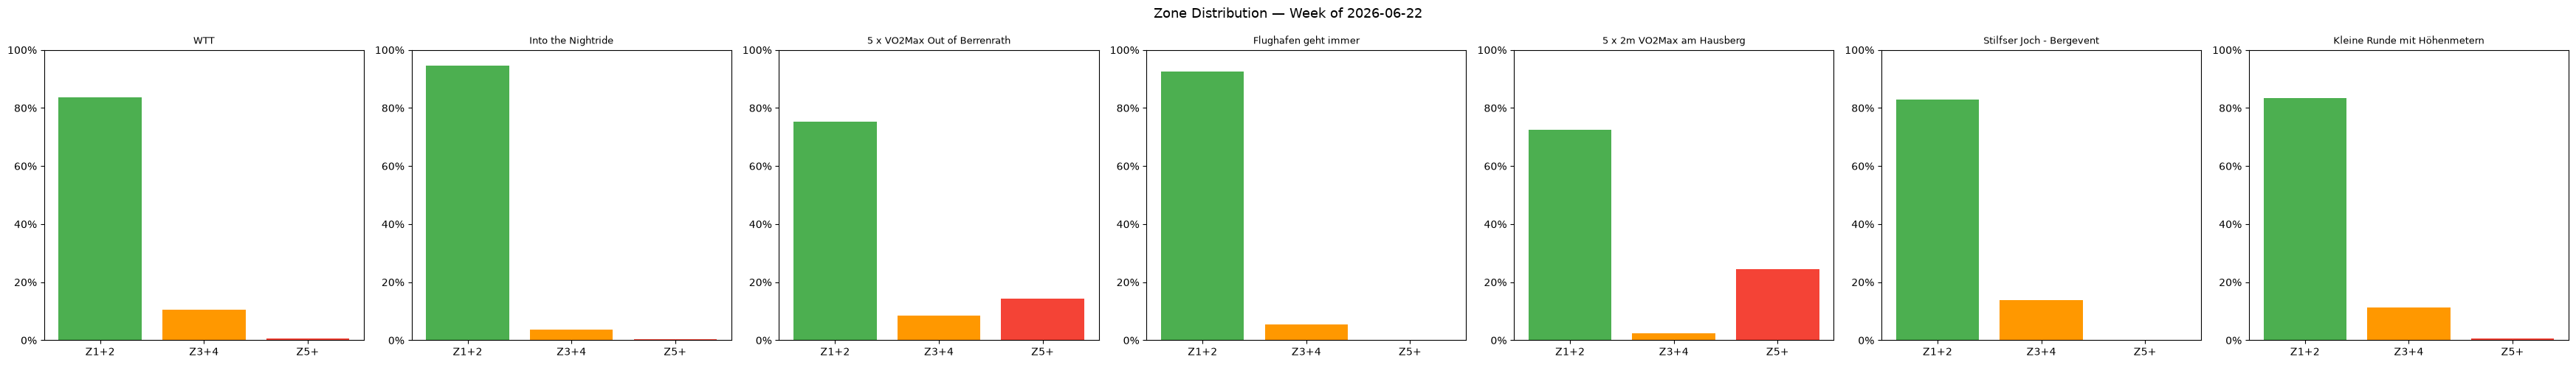

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

zone_df = df[["name", "z1_z2_pct", "z3_z4_pct", "z5_plus_pct"]].dropna()
n = len(zone_df)

if n > 0:
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]
    fig.suptitle(f"Zone Distribution \u2014 Week of {data['week_starting']}", fontsize=13)

    for ax, row in zip(axes, zone_df.itertuples()):
        values = [row.z1_z2_pct, row.z3_z4_pct, row.z5_plus_pct]
        labels = ["Z1+2", "Z3+4", "Z5+"]
        colors = ["#4caf50", "#ff9800", "#f44336"]
        ax.bar(labels, values, color=colors)
        ax.set_title(row.name[:30], fontsize=9)
        ax.set_ylim(0, 100)
        ax.yaxis.set_major_formatter(ticker.PercentFormatter())

    plt.tight_layout()
    plt.show()

## Training Distribution (Polarization Index)

This section summarizes the training distribution label per completed activity and visualizes each ride's zone split to make the weekly intensity profile easy to compare.

,Activity,PI,Label,Tags,Reason,Z1+2 %,Z3+4 %,Z5+ %
Date,,,,,,,,
2026-06-27,WTT,0.67,Pyramidal,"aerobic-threshold-high, lactate-threshold-low","Z1+2 83.6% >= 70%, Z3+4 10.4% >= 10%, Z5+ 0.5%...",83.6,10.4,0.5
2026-06-25,Into the Nightride,1.02,Base,aerobic-threshold-moderate,"Z1+2 94.7% >= 85%, Z3+4 3.7% < 10%, Z5+ 0.4% < 5%",94.7,3.7,0.4
2026-06-24,5 x VO2Max Out of Berrenrath,2.11,Polarized,vo2max-moderate,Z1+2 75.4% >= 70% and Z5+ 14.2% >= 10%,75.4,8.4,14.2
2026-06-22,Flughafen geht immer,0.63,Base,aerobic-threshold-moderate,"Z1+2 92.5% >= 85%, Z3+4 5.4% < 10%, Z5+ 0.2% < 5%",92.5,5.4,0.2
2026-06-20,5 x 2m VO2Max am Hausberg,2.87,HIIT,vo2max-moderate,Z5+ 24.5% >= 20%,72.6,2.4,24.5
2026-06-18,Stilfser Joch - Bergevent,-0.07,Pyramidal,aerobic-threshold-high,"Z1+2 82.8% >= 70%, Z3+4 13.9% >= 10%, Z5+ 0.1%...",82.8,13.9,0.1
2026-06-15,Kleine Runde mit Höhenmetern,0.67,Pyramidal,aerobic-threshold-moderate,"Z1+2 83.4% >= 70%, Z3+4 11.4% >= 10%, Z5+ 0.6%...",83.4,11.4,0.6


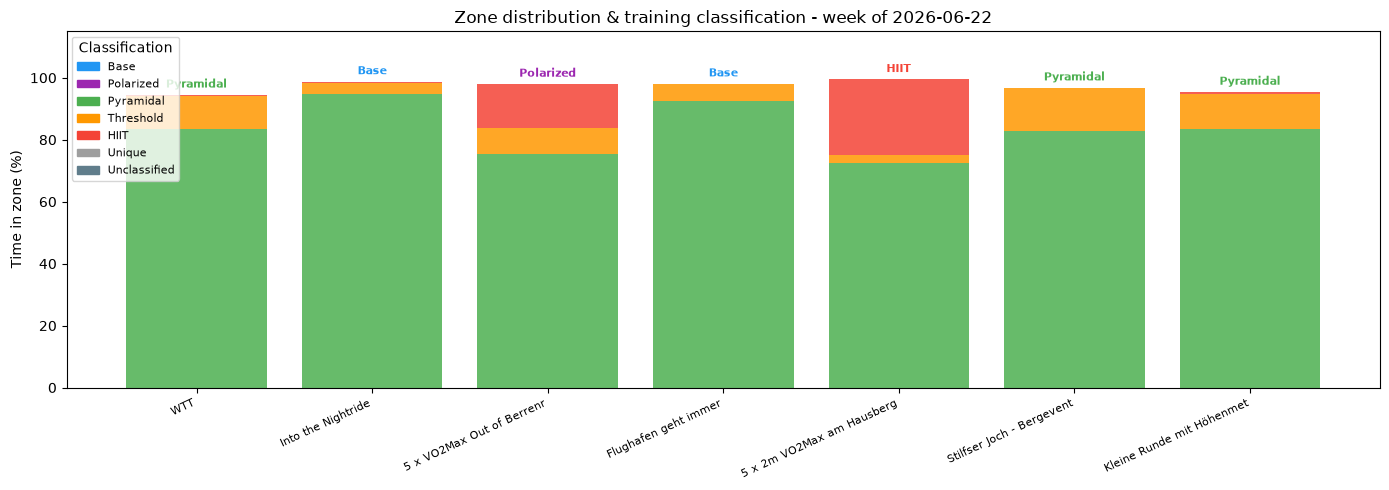


Distribution summary this week:
  Pyramidal    3 ride(s)
  Base         2 ride(s)
  Polarized    1 ride(s)
  HIIT         1 ride(s)


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

_dist_cols = ["date", "name", "polarization_index", "training_distribution", "training_distribution_reason",
              "z1_z2_pct", "z3_z4_pct", "z5_plus_pct"]
if "tags" in df.columns:
    _dist_cols.insert(4, "tags")   # insert between "training_distribution" and "training_distribution_reason"

dist_df = df[_dist_cols].copy()

# Keep rides without classification visible in this block
dist_df["training_distribution"] = dist_df["training_distribution"].fillna("Unclassified")
dist_df["training_distribution_reason"] = dist_df["training_distribution_reason"].fillna(
    "No zone distribution data available"
)

for col in ["z1_z2_pct", "z3_z4_pct", "z5_plus_pct"]:
    if col in dist_df.columns:
        dist_df[col] = dist_df[col].fillna(0)

# Format tags list -> comma-joined string (empty string when absent)
if "tags" in dist_df.columns:
    dist_df["tags"] = dist_df["tags"].apply(
        lambda t: ", ".join(t) if isinstance(t, list) and t else ("" if not t else str(t))
    )

# --- Table: label + reason per ride ---
if not dist_df.empty:
    rename_map = {
        "date": "Date",
        "name": "Activity",
        "polarization_index": "PI",
        "training_distribution": "Label",
        "tags": "Tags",
        "training_distribution_reason": "Reason",
        "z1_z2_pct": "Z1+2 %",
        "z3_z4_pct": "Z3+4 %",
        "z5_plus_pct": "Z5+ %",
    }
    display(dist_df.rename(columns=rename_map).set_index("Date"))

    # --- Bar chart: stacked zone distribution coloured by label ---
    LABEL_COLORS = {
        "Base":         "#2196f3",
        "Polarized":    "#9c27b0",
        "Pyramidal":    "#4caf50",
        "Threshold":    "#ff9800",
        "HIIT":         "#f44336",
        "Unique":       "#9e9e9e",
        "Unclassified": "#607d8b",
    }

    labels = dist_df["training_distribution"].tolist()
    names  = [str(n)[:25] for n in dist_df["name"].tolist()]
    z1z2   = dist_df["z1_z2_pct"].tolist()
    z34    = dist_df["z3_z4_pct"].tolist()
    z5p    = dist_df["z5_plus_pct"].tolist()
    colors = [LABEL_COLORS.get(l, "#9e9e9e") for l in labels]

    x = range(len(names))
    fig, ax = plt.subplots(figsize=(max(8, 2 * len(names)), 5))
    bars1 = ax.bar(x, z1z2, label="Z1+2", color="#4caf50", alpha=0.85)
    bars2 = ax.bar(x, z34,  bottom=z1z2, label="Z3+4", color="#ff9800", alpha=0.85)
    bars3 = ax.bar(x, z5p,  bottom=[a + b for a, b in zip(z1z2, z34)], label="Z5+", color="#f44336", alpha=0.85)

    # Annotate label above each bar group
    for i, (lbl, col) in enumerate(zip(labels, colors)):
        total = z1z2[i] + z34[i] + z5p[i]
        ax.text(i, total + 1.5, lbl, ha="center", va="bottom", fontsize=8,
                fontweight="bold", color=col)

    ax.set_xticks(list(x))
    ax.set_xticklabels(names, rotation=25, ha="right", fontsize=8)
    ax.set_ylabel("Time in zone (%)")
    ax.set_ylim(0, 115)
    ax.set_title(f"Zone distribution & training classification - week of {data.get('week_starting', '')}")
    ax.legend(loc="upper right")

    # Legend patches for classification colours
    patches = [mpatches.Patch(color=c, label=l) for l, c in LABEL_COLORS.items()]
    ax.legend(handles=patches, loc="upper left", fontsize=8, title="Classification")

    plt.tight_layout()
    plt.show()

    # --- Summary: how many rides per label this week ---
    print("\nDistribution summary this week:")
    for lbl, cnt in dist_df["training_distribution"].value_counts().items():
        print(f"  {lbl:<12} {cnt} ride(s)")
else:
    print("No training_distribution data available - run prepare_activities_for_coach.py first.")


## Form & Fatigue Analysis

This section compares current fitness (CTL), fatigue (ATL), and form status, then adds a short coaching interpretation using form zones and HRV.

In [10]:
ctl = data.get("metrics", {}).get("ctl") or 0
atl = data.get("metrics", {}).get("atl") or 0
hrv = data.get("metrics", {}).get("hrv")
ws = data.get("week_summary", {})

form_absolute = ws.get("form_absolute")
form_pct = ws.get("form_pct")
form_percent_display = ws.get("form_percent_display")
form_zone = ws.get("form_zone", "n/a")

form_display = {
    "CTL (Fitness)": round(ctl, 1),
    "ATL (Fatigue)": round(atl, 1),
    "Form (absolute)": form_absolute,
    "Form (%)": f"{form_percent_display:.1f}%" if form_percent_display is not None else "n/a",
    "Form Zone": form_zone,
    "HRV": hrv,
}

display(pd.DataFrame(list(form_display.items()), columns=["Metric", "Value"]).set_index("Metric"))

print("\n=== Coaching Interpretation ===")
# Zones based on form_pct (%), matching intervals.icu definition
if form_pct is not None:
    if form_pct > 0.20:
        print("Form:  Transition (> 20 %) → well rested, consider increasing load")
    elif form_pct >= 0.05:
        print("Form:  Fresh (5–20 %) → race-ready or high-intensity sessions")
    elif form_pct >= -0.10:
        print("Form:  Grey Zone (-10 to 5 %) → moderate fatigue, maintain structure")
        if hrv is not None and hrv < 50:
            print("HRV:   Low HRV signal → consider an easier day")
    elif form_pct >= -0.30:
        print("Form:  Optimal training zone (-30 to -10 %) → proceed with key sessions")
        if hrv is not None and hrv < 50:
            print("HRV:   Strong fatigue signal combined with low HRV → recommend rest day")
    else:
        print("Form:  High fatigue (below -30 %) → reduce intensity and prioritize recovery")
        if hrv is not None and hrv < 50:
            print("HRV:   Strong fatigue signal combined with low HRV → recommend rest day")
else:
    print("Form data not available — run prepare_week_for_coach.py first.")


,Value
Metric,
CTL (Fitness),49.9
ATL (Fatigue),56.3
Form (absolute),-6.4
Form (%),-12.9%
Form Zone,optimal
HRV,57.0



=== Coaching Interpretation ===
Form:  Optimal training zone (-30 to -10 %) → proceed with key sessions


## Form & Fatigue History

This section shows the historical trend of CTL, ATL, and form over time, including the form zones, to track training stress and recovery progression.

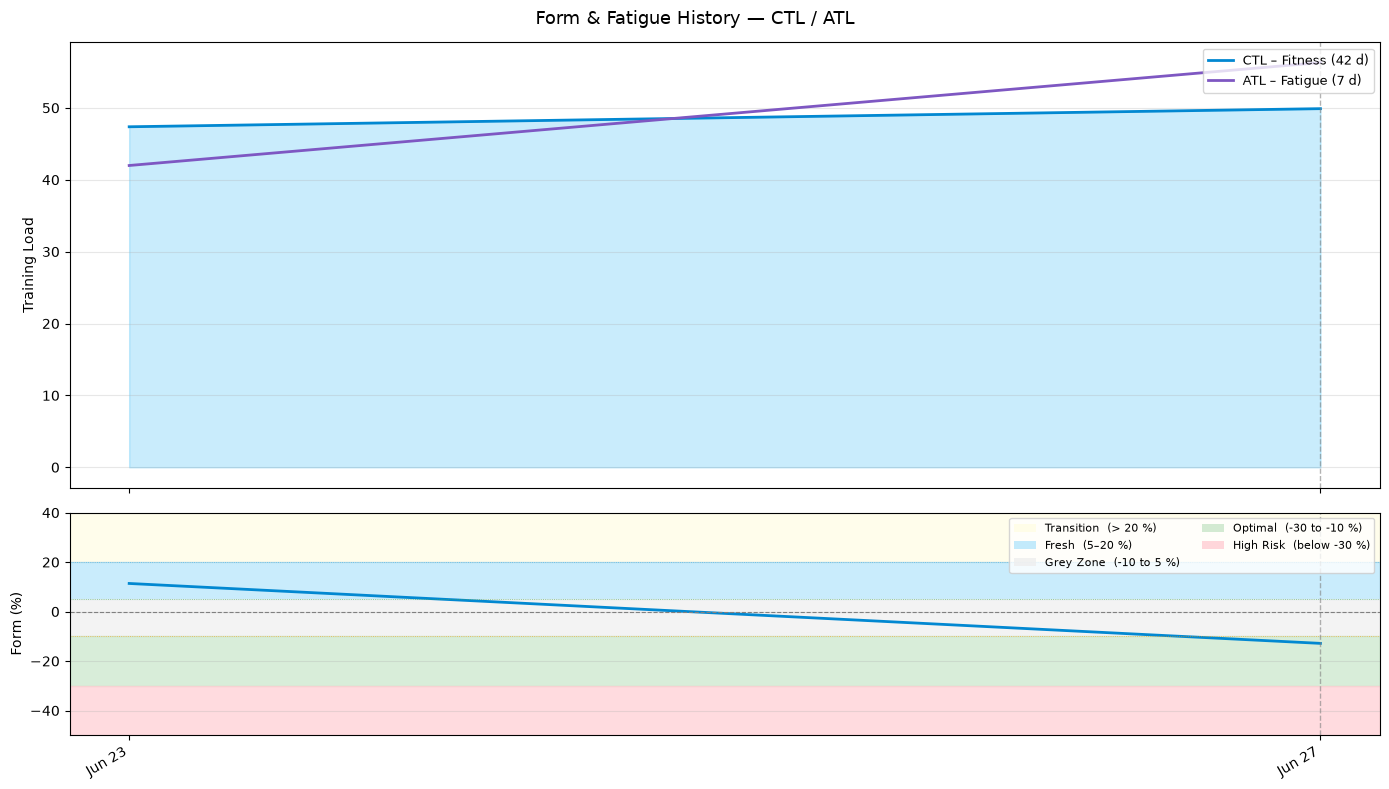


Data points: 2  |  Range: 2026-06-23 → 2026-06-27
Today  →  CTL: 49.9  |  ATL: 56.3  |  Form: -12.9%


In [11]:
import matplotlib.dates as mdates
from matplotlib.patches import Patch

# Load all available metrics snapshots from data/processed/
metrics_files = sorted(PROCESSED_DIR.glob("metrics_*.json"))
hist = []
for f in metrics_files:
    try:
        d = json.loads(f.read_text())
        if d.get("ctl") is not None and d.get("atl") is not None:
            hist.append(d)
    except Exception:
        pass

if len(hist) >= 2:
    dates     = [pd.to_datetime(d["date"]) for d in hist]
    ctl_vals  = [d["ctl"]  for d in hist]
    atl_vals  = [d["atl"]  for d in hist]
    # form_pct in % (matching intervals.icu zone definitions)
    form_vals = [(d["ctl"] - d["atl"]) / d["ctl"] * 100 if d["ctl"] else 0 for d in hist]

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(14, 8), sharex=True,
        gridspec_kw={"height_ratios": [2, 1]}
    )
    fig.suptitle("Form & Fatigue History — CTL / ATL", fontsize=13)

    # ── Top panel: CTL filled area + ATL line ──
    ax1.fill_between(dates, ctl_vals, alpha=0.25, color="#29b6f6")
    ax1.plot(dates, ctl_vals, color="#0288d1", linewidth=2, label="CTL – Fitness (42 d)")
    ax1.plot(dates, atl_vals, color="#7e57c2", linewidth=2, label="ATL – Fatigue (7 d)")
    ax1.set_ylabel("Training Load")
    ax1.legend(loc="upper right", fontsize=9)
    ax1.grid(axis="y", alpha=0.3)

    # ── Bottom panel: form zones (form_pct %, intervals.icu) + form line ──
    ax2.axhspan( 20,  50, color="#fffde7", alpha=0.80, zorder=0)   # Transition (light yellow)
    ax2.axhspan(  5,  20, color="#b3e5fc", alpha=0.70, zorder=0)   # Fresh (light blue)
    ax2.axhspan(-10,   5, color="#eeeeee", alpha=0.70, zorder=0)   # Grey Zone
    ax2.axhspan(-30, -10, color="#c8e6c9", alpha=0.70, zorder=0)   # Optimal (green)
    ax2.axhspan(-60, -30, color="#ffcdd2", alpha=0.70, zorder=0)   # High Risk (red)

    ax2.plot(dates, form_vals, color="#0288d1", linewidth=2, label="Form (%)")
    ax2.axhline(0,  color="grey",    linewidth=0.8, linestyle="--")
    ax2.axhline( 5, color="#4caf50", linewidth=0.6, linestyle=":", alpha=0.7)
    ax2.axhline(20, color="#29b6f6", linewidth=0.6, linestyle=":", alpha=0.7)
    ax2.axhline(-10, color="#ff9800", linewidth=0.6, linestyle=":", alpha=0.7)
    ax2.set_ylabel("Form (%)")
    ax2.set_ylim(-50, 40)

    legend_els = [
        Patch(facecolor="#fffde7", alpha=0.9, label="Transition  (> 20 %)"),
        Patch(facecolor="#b3e5fc", alpha=0.8, label="Fresh  (5–20 %)"),
        Patch(facecolor="#eeeeee", alpha=0.8, label="Grey Zone  (-10 to 5 %)"),
        Patch(facecolor="#c8e6c9", alpha=0.8, label="Optimal  (-30 to -10 %)"),
        Patch(facecolor="#ffcdd2", alpha=0.8, label="High Risk  (below -30 %)"),
    ]
    ax2.legend(handles=legend_els, loc="upper right", fontsize=8, ncol=2)
    ax2.grid(axis="y", alpha=0.3)

    # Set ticks only at actual data dates to avoid duplicates with sparse history
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    if len(dates) <= 60:
        ax2.set_xticks(dates)
    else:
        ax2.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    plt.xticks(rotation=30, ha="right")

    # Mark today
    today_ts = pd.Timestamp.today().normalize()
    for ax in (ax1, ax2):
        ax.axvline(today_ts, color="grey", linewidth=1, linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()

    print(f"\nData points: {len(hist)}  |  Range: {hist[0]['date']} → {hist[-1]['date']}")
    print(f"Today  →  CTL: {ctl_vals[-1]:.1f}  |  ATL: {atl_vals[-1]:.1f}  |  Form: {form_vals[-1]:.1f}%")
else:
    print(f"Not enough historical data ({len(hist)} snapshot(s) found).")
    print("Run get_metrics.py on multiple days to build up a history.")


## Integrated Fatigue & Fueling Analysis

This section combines form and fueling metrics to assess whether current fatigue may be limited by insufficient carbohydrate intake and gives practical recommendations.

In [12]:
ff = ws.get("fueling_form_analysis", {})

if ff:
    form_pct_display = ws.get('form_percent_display', 0)
    interpretation = ff.get('interpretation', '')
    recommendation = ff.get('recommendation', '')
    long_ride_advice = ff.get('long_ride_advice')

    ff_display = {
        "Form (%)": f"{form_pct_display:.1f}%",
        "Fatigue Status": ff.get("fatigue_status"),
        "Avg Carbs/h (g)": ff.get("avg_carbs_per_hour"),
        "Fueling Status": ff.get("fueling_status"),
        "Underfueled Sessions": ff.get("underfueled_sessions"),
        "Durability Limited by Fueling": ff.get("durability_limited_by_fueling"),
        "Long Rides": ff.get("number_of_long_rides"),
    }
    display(pd.DataFrame(list(ff_display.items()), columns=["Metric", "Value"]).set_index("Metric"))
    print()
    print(f"Interpretation: {interpretation}")
    print(f"Recommendation: {recommendation}")
    if long_ride_advice:
        print(f"Long rides:     {long_ride_advice}")
else:
    print("No integrated analysis available — run prepare_week_for_coach.py first.")


,Value
Metric,
Form (%),-12.9%
Fatigue Status,optimal
Avg Carbs/h (g),61.4
Fueling Status,moderate
Underfueled Sessions,0
Durability Limited by Fueling,False
Long Rides,2



Interpretation: Fatigue is appropriate and productive
Recommendation: Continue with planned VO2 and threshold sessions


## Fueling Analysis

This section summarizes fueling quality for completed activities, including carbs per hour, fueling ratio, underfueled sessions, and weekly recommendations.

In [13]:
fueling = data.get("fueling_analysis", {})
fa = fueling.get("activities", [])

if fa:
    df_fuel = pd.DataFrame(fa)
    fuel_cols = [
        "date", "name", "duration_hours", "fueling_status", "ride_type",
        "carbs_per_hour", "carbs_classification", "fueling_ratio",
        "ratio_classification", "is_long_ride", "flags",
    ]
    fuel_cols = [c for c in fuel_cols if c in df_fuel.columns]
    display(df_fuel[fuel_cols])

    fs = fueling.get("weekly_summary", {})
    print(f"\nLong rides:           {fs.get('number_of_long_rides')}")
    print(f"Avg carbs/h:          {fs.get('avg_carbs_per_hour')} g")
    print(f"Avg fueling ratio:    {fs.get('avg_fueling_ratio')}")
    print(f"Underfueled sessions: {fs.get('number_of_underfueled_sessions')}")

    print("\nRecommendations:")
    for r in fueling.get("recommendations", []):
        print(f"  * {r}")

,date,name,duration_hours,fueling_status,ride_type,carbs_per_hour,carbs_classification,fueling_ratio,ratio_classification,is_long_ride,flags
0,2026-06-27,WTT,3.68,fueling required,threshold,97.8,good,0.87,good,True,[]
1,2026-06-25,Into the Nightride,2.46,fueling required,endurance,65.0,moderate,0.63,acceptable,False,[]
2,2026-06-24,5 x VO2Max Out of Berrenrath,1.54,fueling optional,vo2,48.7,optional,0.28,optional,False,[]
3,2026-06-22,Flughafen geht immer,1.98,fueling optional,endurance,40.4,optional,0.32,optional,False,[]
4,2026-06-20,5 x 2m VO2Max am Hausberg,0.65,no fueling needed,vo2,0.0,not required,0.00,not applicable,False,[]
5,2026-06-18,Stilfser Joch - Bergevent,5.61,fueling required,long_ride,89.1,good,0.83,good,True,[]
6,2026-06-15,Kleine Runde mit Höhenmetern,1.46,no fueling needed,endurance,27.4,not required,0.20,not applicable,False,[]



Long rides:           2
Avg carbs/h:          61.4 g
Avg fueling ratio:    0.45
Underfueled sessions: 0

Recommendations:
  * Short rides do not require fueling — focus on long sessions.


## Planned Workouts

This section lists planned workouts for the current and next week with planned load and intended zone distribution.

In [14]:
planned = data.get("planned_workouts")

def _show_planned_table(workouts: list, week_label: str) -> None:
    if not workouts:
        print(f"{week_label}: no planned workouts found.")
        return

    rows = []
    for w in workouts:
        zd = w.get("zone_distribution") or {}
        rows.append({
            "Date": w.get("date"),
            "Time": w.get("time"),
            "Name": w.get("name"),
            "Type": w.get("type"),
            "Duration (h)": w.get("duration_hours"),
            "Planned Load": w.get("planned_load"),
            "Z1+2 %": zd.get("z1_z2_pct"),
            "Z3+4 %": zd.get("z3_z4_pct"),
            "Z5+ %": zd.get("z5_plus_pct"),
        })

    df_plan = pd.DataFrame(rows).set_index("Date")
    print(f"\n### {week_label}")
    display(df_plan)


if planned:
    _show_planned_table(
        planned.get("current_week", {}).get("planned_workouts", []),
        f"Current week  ({planned.get('current_week', {}).get('week_starting', '')})",
    )
    _show_planned_table(
        planned.get("next_week", {}).get("planned_workouts", []),
        f"Next week  ({planned.get('next_week', {}).get('week_starting', '')})",
    )
else:
    print("No planned workout data available — run prepare_week_for_coach.py first.")



### Current week  (2026-06-22)


,Time,Name,Type,Duration (h),Planned Load,Z1+2 %,Z3+4 %,Z5+ %
Date,,,,,,,,
2026-06-27,00:00,WTT,Ride,4.0,160,None,None,None
2026-06-28,00:00,Schattige Täler,Ride,3.0,120,None,None,None


Next week  (2026-06-29): no planned workouts found.


### Workout Step Structure

This section visualizes the internal step structure of planned workouts as power-over-time blocks based on percentage of FTP.

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


def _zone_color(pct_ftp: float | None) -> str:
    """Return a color based on % FTP to visualise intensity."""
    if pct_ftp is None:
        return "#9e9e9e"
    if pct_ftp < 56:
        return "#4caf50"   # Z1 – Active Recovery
    if pct_ftp < 76:
        return "#8bc34a"   # Z2 – Endurance
    if pct_ftp < 91:
        return "#ffeb3b"   # Z3 – Tempo
    if pct_ftp < 106:
        return "#ff9800"   # Z4 – Threshold
    if pct_ftp < 121:
        return "#f44336"   # Z5 – VO2max
    return "#9c27b0"       # Z6+ – Anaerobic / Neuromuscular


def _plot_workout_steps(ax: plt.Axes, steps: list[dict], title: str) -> None:
    """Draw a horizontal step-bar chart (power-over-time style) on ax."""
    if not steps:
        ax.text(0.5, 0.5, "No steps", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title[:40], fontsize=8)
        return

    x = 0.0
    for step in steps:
        dur = step.get("duration_min") or 0
        pct = step.get("power_pct_ftp")
        height = pct if pct is not None else 0
        color = _zone_color(pct)
        ax.bar(x + dur / 2, height, width=dur, color=color, align="center", edgecolor="white", linewidth=0.5)
        if dur >= 4:
            ax.text(x + dur / 2, height / 2, f"{pct}%", ha="center", va="center",
                    fontsize=7, color="white", fontweight="bold")
        x += dur

    ax.set_xlim(0, x)
    ax.set_ylim(0, 130)
    ax.set_xlabel("Duration (min)", fontsize=7)
    ax.set_ylabel("% FTP", fontsize=7)
    ax.set_title(title[:40], fontsize=8)
    ax.tick_params(labelsize=7)
    # FTP reference line
    ax.axhline(100, color="black", linewidth=0.8, linestyle="--", alpha=0.5)


def _collect_workouts_with_steps(planned: dict) -> list[dict]:
    result = []
    for week_key in ("current_week", "next_week"):
        week = planned.get(week_key, {})
        for w in week.get("planned_workouts", []):
            steps = w.get("steps")
            if steps:
                result.append(w)
    return result


if planned:
    workouts_with_steps = _collect_workouts_with_steps(planned)
    if workouts_with_steps:
        n = len(workouts_with_steps)
        ncols = min(n, 3)
        nrows = (n + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4 * nrows))
        axes_flat = np.array(axes).flatten() if n > 1 else [axes]

        for ax, w in zip(axes_flat, workouts_with_steps):
            title = f"{w.get('date')}  {w.get('name', '')}"
            _plot_workout_steps(ax, w.get("steps", []), title)

        # Hide unused subplots
        for ax in axes_flat[n:]:
            ax.set_visible(False)

        # Zone legend
        zone_labels = [
            ("<56% Z1 Recovery", "#4caf50"),
            ("56–75% Z2 Endurance", "#8bc34a"),
            ("76–90% Z3 Tempo", "#ffeb3b"),
            ("91–105% Z4 Threshold", "#ff9800"),
            ("106–120% Z5 VO2max", "#f44336"),
            ("121%+ Z6 Anaerobic", "#9c27b0"),
        ]
        patches = [mpatches.Patch(facecolor=c, label=l) for l, c in zone_labels]
        fig.legend(handles=patches, loc="lower center", ncol=3, fontsize=8,
                   bbox_to_anchor=(0.5, -0.02))

        fig.suptitle("Planned Workout Steps — Power over Duration", fontsize=12)
        plt.tight_layout()
        plt.show()
    else:
        print("No workouts with step data available.")
else:
    print("No planned workout data available — run prepare_week_for_coach.py first.")


No workouts with step data available.


## W'bal Analysis

Detailed anaerobic reserve analysis for high-intensity activities.
Computed from the second-by-second power stream (Skiba differential model).
Only activities meeting at least one intensity criterion (≥8 % Z5+, interval ≥105 % FTP / ≥2 min, or vo2 / event tag) receive a W'bal summary.


,Date,W' (J),Min W'bal (J),Depletion (J),Usage (%),s < 30 %,s < 10 %,Depletion Events,Recovery Ratio
Activity,,,,,,,,,
5 x VO2Max Out of Berrenrath,2026-06-24,20434.0,10055.1,10378.9,50.8,0,0,0,None
5 x 2m VO2Max am Hausberg,2026-06-20,20434.0,10498.4,9935.6,48.6,0,0,0,None


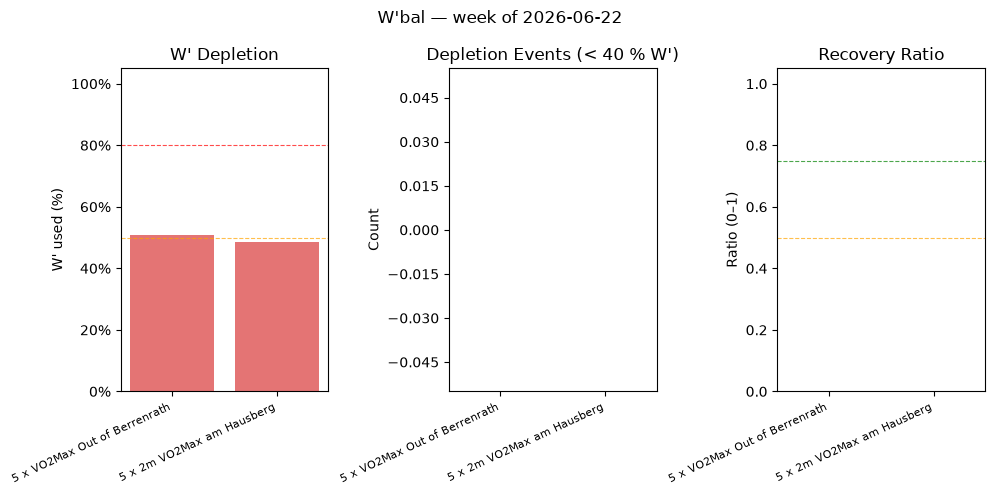

In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

wbal_rows = []
for act in data.get("activities", []):
    ws = act.get("wbal_summary")
    if not ws:
        continue
    wbal_rows.append({
        "Activity":             act.get("name", ""),
        "Date":                 act.get("date", ""),
        "W' (J)":               ws.get("w_prime_j"),
        "Min W'bal (J)":        ws.get("wbal_min_j"),
        "Depletion (J)":        ws.get("wbal_max_depletion_j"),
        "Usage (%)":            ws.get("wbal_usage_pct"),
        "s < 30 %":             ws.get("seconds_below_30pct"),
        "s < 10 %":             ws.get("seconds_below_10pct"),
        "Depletion Events":     ws.get("wbal_depletion_events"),
        "Recovery Ratio":       ws.get("wbal_recovery_ratio"),
    })

if wbal_rows:
    wbal_df = pd.DataFrame(wbal_rows).set_index("Activity")
    display(wbal_df)

    # --- Bar chart: W' usage per activity ---
    names      = [r["Activity"][:28] for r in wbal_rows]
    usage_pct  = [r["Usage (%)"] or 0 for r in wbal_rows]
    events     = [r["Depletion Events"] or 0 for r in wbal_rows]
    rec_ratios = [r["Recovery Ratio"] for r in wbal_rows]

    x = list(range(len(names)))
    fig, axes = plt.subplots(1, 3, figsize=(max(10, 3.5 * len(names)), 5))
    fig.suptitle(f"W'bal — week of {data.get('week_starting', '')}", fontsize=12)

    # Panel 1: W' usage %
    axes[0].bar(x, usage_pct, color="#e05c5c", alpha=0.85)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(names, rotation=25, ha="right", fontsize=8)
    axes[0].set_ylabel("W' used (%)")
    axes[0].set_ylim(0, 105)
    axes[0].yaxis.set_major_formatter(ticker.PercentFormatter())
    axes[0].set_title("W' Depletion")
    axes[0].axhline(50, color="orange", linestyle="--", linewidth=0.8, alpha=0.7)
    axes[0].axhline(80, color="red",    linestyle="--", linewidth=0.8, alpha=0.7)

    # Panel 2: Depletion events count
    axes[1].bar(x, events, color="#5c8ee0", alpha=0.85)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(names, rotation=25, ha="right", fontsize=8)
    axes[1].set_ylabel("Count")
    axes[1].yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    axes[1].set_title("Depletion Events (< 40 % W')")

    # Panel 3: Recovery ratio
    rec_vals = [r if r is not None else 0 for r in rec_ratios]
    bar_colors = ["#4caf50" if v >= 0.75 else "#ff9800" if v >= 0.5 else "#f44336" for v in rec_vals]
    axes[2].bar(x, rec_vals, color=bar_colors, alpha=0.85)
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(names, rotation=25, ha="right", fontsize=8)
    axes[2].set_ylabel("Ratio (0–1)")
    axes[2].set_ylim(0, 1.05)
    axes[2].set_title("Recovery Ratio")
    axes[2].axhline(0.75, color="green",  linestyle="--", linewidth=0.8, alpha=0.7)
    axes[2].axhline(0.50, color="orange", linestyle="--", linewidth=0.8, alpha=0.7)

    plt.tight_layout()
    plt.show()
else:
    print("No W'bal data available — run prepare_activities_for_coach.py first.")
    print("(Only activities with ≥8 % Z5+, high-intensity intervals, vo2 or event tags are analysed.)")
